# Data Information

This dataset contains insurance cost information for 25,000 applicants from various cities in India. It includes demographic, health, and lifestyle variables such as age, gender, BMI, cholesterol level, smoking status, exercise habits, alcohol consumption, and more. The target variable is `insurance_cost`, which represents the insurance premium charged to the individual.

# Dataset

In [1]:
import pandas as pd

data_df = pd.read_csv("Data.csv")
data_df.head(10)

,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,...,smoking_status,Year_last_admitted,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost
0,5000,3,1,1,Salried,2,125 to 150,4866,28,1,...,Unknown,NaN,Chennai,67,N,Rare,Moderate,1,25,20978
1,5001,0,0,0,Student,4,150 to 175,6411,50,0,...,formerly smoked,NaN,Jaipur,58,N,Rare,Moderate,3,27,6170
2,5002,1,0,0,Business,4,200 to 225,4509,68,0,...,formerly smoked,NaN,Jaipur,73,N,Daily,Extreme,0,32,28382
3,5003,7,4,0,Business,2,175 to 200,6214,51,0,...,Unknown,NaN,Chennai,71,Y,Rare,No,3,37,27148
4,5004,3,1,0,Student,2,150 to 175,4938,44,0,...,never smoked,2004.0,Bangalore,74,N,No,Extreme,0,34,29616
5,5005,8,0,0,Salried,2,225 to 250,5306,39,0,...,Unknown,2003.0,Bhubaneswar,78,Y,Rare,No,3,13,39488
6,5006,8,0,0,Student,4,125 to 150,4676,40,0,...,never smoked,2004.0,Guwahati,81,N,No,Moderate,3,16,37020
7,5007,1,0,0,Student,4,150 to 175,7448,46,0,...,smokes,NaN,Chennai,72,N,Rare,Moderate,0,34,29616
8,5008,8,1,0,Salried,4,125 to 150,5632,45,0,...,smokes,2007.0,Mumbai,67,Y,Rare,No,1,12,22212
9,5009,4,3,0,Salried,3,125 to 150,4130,38,0,...,formerly smoked,NaN,Nagpur,63,N,Daily,Moderate,0,12,8638


# Problem Definition

## Objective

- Use the dataset to estimate insurance cost per applicant
- Identify which variables are most associated with higher or lower insurance cost

## Usecase

Corporate Wellness Program
- Identify high-risk employees based on predicted insurance costs
- Enable targeted interventions to reduce the company's overall healthcare expenses

Insurance Company
- Analyze insurance cost trends across different population segments
- Enable dynamic premium pricing based on individual risk profiles
- Provide personalized insurance plans tailored to each customer

Example Use Case
An applicant with certain health conditions and lifestyle factors who is predicted to have high insurance costs can be recommended lifestyle interventions or appropriate coverage plans

# Data Preparation

## 1. Data Understanding

In [2]:
print("Shape:", data_df.shape)

Shape: (25000, 24)


In [3]:
print("Columns:", data_df.columns.tolist())

Columns: ['applicant_id', 'years_of_insurance_with_us', 'regular_checkup_lasy_year', 'adventure_sports', 'Occupation', 'visited_doctor_last_1_year', 'cholesterol_level', 'daily_avg_steps', 'age', 'heart_decs_history', 'other_major_decs_history', 'Gender', 'avg_glucose_level', 'bmi', 'smoking_status', 'Year_last_admitted', 'Location', 'weight', 'covered_by_any_other_company', 'Alcohol', 'exercise', 'weight_change_in_last_one_year', 'fat_percentage', 'insurance_cost']


In [4]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   applicant_id                    25000 non-null  int64  
 1   years_of_insurance_with_us      25000 non-null  int64  
 2   regular_checkup_lasy_year       25000 non-null  int64  
 3   adventure_sports                25000 non-null  int64  
 4   Occupation                      25000 non-null  str    
 5   visited_doctor_last_1_year      25000 non-null  int64  
 6   cholesterol_level               25000 non-null  str    
 7   daily_avg_steps                 25000 non-null  int64  
 8   age                             25000 non-null  int64  
 9   heart_decs_history              25000 non-null  int64  
 10  other_major_decs_history        25000 non-null  int64  
 11  Gender                          25000 non-null  str    
 12  avg_glucose_level               25000 non-n

In [5]:
data_df.isnull().sum()

applicant_id                          0
years_of_insurance_with_us            0
regular_checkup_lasy_year             0
adventure_sports                      0
Occupation                            0
visited_doctor_last_1_year            0
cholesterol_level                     0
daily_avg_steps                       0
age                                   0
heart_decs_history                    0
other_major_decs_history              0
Gender                                0
avg_glucose_level                     0
bmi                                 990
smoking_status                        0
Year_last_admitted                11881
Location                              0
weight                                0
covered_by_any_other_company          0
Alcohol                               0
exercise                              0
weight_change_in_last_one_year        0
fat_percentage                        0
insurance_cost                        0
dtype: int64

In [6]:
data_df.duplicated().sum()

np.int64(0)

In [7]:
data_df = data_df.drop_duplicates()
data_df.duplicated().sum()

np.int64(0)

In [8]:
data_df.describe().round(2)

,applicant_id,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,visited_doctor_last_1_year,daily_avg_steps,age,heart_decs_history,other_major_decs_history,avg_glucose_level,bmi,Year_last_admitted,weight,weight_change_in_last_one_year,fat_percentage,insurance_cost
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.0,25000.00,24010.00,13119.00,25000.00,25000.00,25000.00,25000.00
mean,17499.50,4.09,0.77,0.08,3.10,5215.89,44.92,0.05,0.1,167.53,31.39,2003.89,71.61,2.52,28.81,27147.41
std,7217.02,2.61,1.20,0.27,1.14,1053.18,16.11,0.23,0.3,62.73,7.88,7.58,9.33,1.69,8.63,14323.69
min,5000.00,0.00,0.00,0.00,0.00,2034.00,16.00,0.00,0.0,57.00,12.30,1990.00,52.00,0.00,11.00,2468.00
25%,11249.75,2.00,0.00,0.00,2.00,4543.00,31.00,0.00,0.0,113.00,26.10,1997.00,64.00,1.00,21.00,16042.00
50%,17499.50,4.00,0.00,0.00,3.00,5089.00,45.00,0.00,0.0,168.00,30.50,2004.00,72.00,3.00,31.00,27148.00
75%,23749.25,6.00,1.00,0.00,4.00,5730.00,59.00,0.00,0.0,222.00,35.60,2010.00,78.00,4.00,36.00,37020.00
max,29999.00,8.00,5.00,1.00,12.00,11255.00,74.00,1.00,1.0,277.00,100.60,2018.00,96.00,6.00,42.00,67870.00


In [9]:
data_df.describe(include="object")

/var/folders/ym/l0yt0mwj07lgpgk2c8rbc34h0000gn/T/ipykernel_14693/440191773.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data_df.describe(include="object")


,Occupation,cholesterol_level,Gender,smoking_status,Location,covered_by_any_other_company,Alcohol,exercise
count,25000,25000,25000,25000,25000,25000,25000,25000
unique,3,5,2,4,15,2,3,3
top,Student,150 to 175,Male,never smoked,Bangalore,N,Rare,Moderate
freq,10169,8763,16422,9249,1742,17418,13752,14638


# 2. Data Cleaning

## 2.1 Drop ID Column

In [10]:
data_df = data_df.drop(columns=['applicant_id'])
print("Shape after dropping applicant_id:", data_df.shape)

Shape after dropping applicant_id: (25000, 23)


## 2.2 Missing Values

In [11]:
print("Missing values:")
missing = data_df.isnull().sum()
print(missing[missing > 0])
print(f"\nbmi missing: {data_df['bmi'].isnull().sum()} ({data_df['bmi'].isnull().mean()*100:.1f}%)")
print(f"Year_last_admitted missing: {data_df['Year_last_admitted'].isnull().sum()} ({data_df['Year_last_admitted'].isnull().mean()*100:.1f}%)")

Missing values:
bmi                     990
Year_last_admitted    11881
dtype: int64

bmi missing: 990 (4.0%)
Year_last_admitted missing: 11881 (47.5%)


In [12]:
data_df['bmi'] = data_df['bmi'].fillna(data_df['bmi'].median())
print(f"bmi missing after imputation: {data_df['bmi'].isnull().sum()}")

bmi missing after imputation: 0


In [13]:
data_df['was_admitted'] = data_df['Year_last_admitted'].notna().astype(int)
data_df = data_df.drop(columns=['Year_last_admitted'])
print("was_admitted value counts:")
print(data_df['was_admitted'].value_counts())

was_admitted value counts:
was_admitted
1    13119
0    11881
Name: count, dtype: int64


In [14]:
print("Remaining missing values:", data_df.isnull().sum().sum())

Remaining missing values: 0


## 2.3 Outlier

In [15]:
num_cols = ['age', 'bmi', 'avg_glucose_level', 'daily_avg_steps', 'weight', 'fat_percentage', 'insurance_cost']

for col in num_cols:
    Q1 = data_df[col].quantile(0.25)
    Q3 = data_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = data_df[(data_df[col] < lower) | (data_df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers (lower={lower:.1f}, upper={upper:.1f})")

age: 0 outliers (lower=-11.0, upper=101.0)
bmi: 624 outliers (lower=12.8, upper=48.8)
avg_glucose_level: 0 outliers (lower=-50.5, upper=385.5)
daily_avg_steps: 952 outliers (lower=2762.5, upper=7510.5)
weight: 0 outliers (lower=43.0, upper=99.0)
fat_percentage: 0 outliers (lower=-1.5, upper=58.5)
insurance_cost: 0 outliers (lower=-15425.0, upper=68487.0)


Outliers in numeric features are retained as they represent real-world variability in health metrics.

Outlier insurance_cost are retained because they are the target variable that the model must predict.

In [16]:
data_df['Occupation'].value_counts()

Occupation
Student     10169
Business    10020
Salried      4811
Name: count, dtype: int64

In [17]:
data_df['cholesterol_level'].value_counts()

cholesterol_level
150 to 175    8763
125 to 150    8339
200 to 225    2963
175 to 200    2881
225 to 250    2054
Name: count, dtype: int64

In [18]:
data_df['Gender'].value_counts()

Gender
Male      16422
Female     8578
Name: count, dtype: int64

In [19]:
data_df['smoking_status'].value_counts()

smoking_status
never smoked       9249
Unknown            7555
formerly smoked    4329
smokes             3867
Name: count, dtype: int64

In [20]:
data_df['Location'].value_counts()

Location
Bangalore      1742
Jaipur         1706
Bhubaneswar    1704
Mangalore      1697
Delhi          1680
Ahmedabad      1677
Guwahati       1672
Chennai        1669
Kanpur         1664
Nagpur         1663
Mumbai         1658
Lucknow        1637
Pune           1622
Kolkata        1620
Surat          1589
Name: count, dtype: int64

In [21]:
data_df['Alcohol'].value_counts()

Alcohol
Rare     13752
No        8541
Daily     2707
Name: count, dtype: int64

In [22]:
data_df['exercise'].value_counts()

exercise
Moderate    14638
Extreme      5248
No           5114
Name: count, dtype: int64

In [23]:
data_df['covered_by_any_other_company'].value_counts()

covered_by_any_other_company
N    17418
Y     7582
Name: count, dtype: int64

# 3. Data Transformation

## 3.1 Feature Encoding

In [24]:
data_df['gender_encoded'] = data_df['Gender'].map({'Male': 0, 'Female': 1})
data_df.head(5)

,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,other_major_decs_history,...,Location,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost,was_admitted,gender_encoded
0,3,1,1,Salried,2,125 to 150,4866,28,1,0,...,Chennai,67,N,Rare,Moderate,1,25,20978,0,0
1,0,0,0,Student,4,150 to 175,6411,50,0,0,...,Jaipur,58,N,Rare,Moderate,3,27,6170,0,0
2,1,0,0,Business,4,200 to 225,4509,68,0,0,...,Jaipur,73,N,Daily,Extreme,0,32,28382,0,1
3,7,4,0,Business,2,175 to 200,6214,51,0,0,...,Chennai,71,Y,Rare,No,3,37,27148,0,1
4,3,1,0,Student,2,150 to 175,4938,44,0,1,...,Bangalore,74,N,No,Extreme,0,34,29616,1,0


In [25]:
data_df['covered_other_encoded'] = data_df['covered_by_any_other_company'].map({'N': 0, 'Y': 1})
data_df.head(5)

,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,Occupation,visited_doctor_last_1_year,cholesterol_level,daily_avg_steps,age,heart_decs_history,other_major_decs_history,...,weight,covered_by_any_other_company,Alcohol,exercise,weight_change_in_last_one_year,fat_percentage,insurance_cost,was_admitted,gender_encoded,covered_other_encoded
0,3,1,1,Salried,2,125 to 150,4866,28,1,0,...,67,N,Rare,Moderate,1,25,20978,0,0,0
1,0,0,0,Student,4,150 to 175,6411,50,0,0,...,58,N,Rare,Moderate,3,27,6170,0,0,0
2,1,0,0,Business,4,200 to 225,4509,68,0,0,...,73,N,Daily,Extreme,0,32,28382,0,1,0
3,7,4,0,Business,2,175 to 200,6214,51,0,0,...,71,Y,Rare,No,3,37,27148,0,1,1
4,3,1,0,Student,2,150 to 175,4938,44,0,1,...,74,N,No,Extreme,0,34,29616,1,0,0


In [26]:
alcohol_map = {'No': 0, 'Rare': 1, 'Daily': 2}
data_df['alcohol_encoded'] = data_df['Alcohol'].map(alcohol_map)

exercise_map = {'No': 0, 'Moderate': 1, 'Extreme': 2}
data_df['exercise_encoded'] = data_df['exercise'].map(exercise_map)

data_df[['Alcohol', 'alcohol_encoded', 'exercise', 'exercise_encoded']].head()

,Alcohol,alcohol_encoded,exercise,exercise_encoded
0,Rare,1,Moderate,1
1,Rare,1,Moderate,1
2,Daily,2,Extreme,2
3,Rare,1,No,0
4,No,0,Extreme,2


In [27]:
from sklearn.preprocessing import OneHotEncoder

ohe_cols = ['Occupation', 'cholesterol_level', 'smoking_status', 'Location']
encoder = OneHotEncoder(sparse_output=False, drop='first')

encoded_arr = encoder.fit_transform(data_df[ohe_cols])
encoded_columns = encoder.get_feature_names_out(ohe_cols)
encoded_df = pd.DataFrame(encoded_arr, columns=encoded_columns, index=data_df.index)

data_df = data_df.drop(columns=ohe_cols)
data_df = pd.concat([data_df, encoded_df], axis=1)

print("Shape after encoding:", data_df.shape)
data_df.head(5)

Shape after encoding: (25000, 46)


,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,visited_doctor_last_1_year,daily_avg_steps,age,heart_decs_history,other_major_decs_history,Gender,avg_glucose_level,...,Location_Guwahati,Location_Jaipur,Location_Kanpur,Location_Kolkata,Location_Lucknow,Location_Mangalore,Location_Mumbai,Location_Nagpur,Location_Pune,Location_Surat
0,3,1,1,2,4866,28,1,0,Male,97,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,4,6411,50,0,0,Male,212,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,0,4,4509,68,0,0,Female,166,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7,4,0,2,6214,51,0,0,Female,109,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3,1,0,2,4938,44,0,1,Male,118,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
data_df = data_df.drop(columns=['Gender', 'covered_by_any_other_company', 'Alcohol', 'exercise'])
print("Final shape:", data_df.shape)
data_df.head(5)

Final shape: (25000, 42)


,years_of_insurance_with_us,regular_checkup_lasy_year,adventure_sports,visited_doctor_last_1_year,daily_avg_steps,age,heart_decs_history,other_major_decs_history,avg_glucose_level,bmi,...,Location_Guwahati,Location_Jaipur,Location_Kanpur,Location_Kolkata,Location_Lucknow,Location_Mangalore,Location_Mumbai,Location_Nagpur,Location_Pune,Location_Surat
0,3,1,1,2,4866,28,1,0,97,31.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,0,4,6411,50,0,0,212,34.2,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0,0,4,4509,68,0,0,166,40.4,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7,4,0,2,6214,51,0,0,109,22.9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3,1,0,2,4938,44,0,1,118,26.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Data Analysis

## 1. Descriptive Statistics

In [29]:
data_df[['age', 'bmi', 'avg_glucose_level', 'daily_avg_steps', 'weight', 'fat_percentage', 'insurance_cost']].describe().round(2)

,age,bmi,avg_glucose_level,daily_avg_steps,weight,fat_percentage,insurance_cost
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00
mean,44.92,31.36,167.53,5215.89,71.61,28.81,27147.41
std,16.11,7.72,62.73,1053.18,9.33,8.63,14323.69
min,16.00,12.30,57.00,2034.00,52.00,11.00,2468.00
25%,31.00,26.30,113.00,4543.00,64.00,21.00,16042.00
50%,45.00,30.50,168.00,5089.00,72.00,31.00,27148.00
75%,59.00,35.30,222.00,5730.00,78.00,36.00,37020.00
max,74.00,100.60,277.00,11255.00,96.00,42.00,67870.00


## 2. Inferential Statistics

## 2.1 Normality Test

In [30]:
from scipy import stats

stat, p = stats.shapiro(data_df['insurance_cost'].sample(5000, random_state=42))
print(f"Shapiro-Wilk (sample 5000): stat={stat:.4f}, p-value={p:.6f}")
print(f"Skewness: {data_df['insurance_cost'].skew():.2f}")

Shapiro-Wilk (sample 5000): stat=0.9705, p-value=0.000000
Skewness: 0.33


The Shapiro-Wilk test rejects normality (p < 0.05), so we use non-parametric tests. A sample of 5000 is used because Shapiro-Wilk has a maximum input size limit.

## 2.2 Binary Features VS Insurance Cost (Mann-Whitney U Test)

In [31]:
from scipy.stats import mannwhitneyu

binary_cols = ['gender_encoded', 'covered_other_encoded', 'adventure_sports', 'heart_decs_history', 'other_major_decs_history', 'was_admitted']

for col in binary_cols:
    group_0 = data_df[data_df[col] == 0]['insurance_cost']
    group_1 = data_df[data_df[col] == 1]['insurance_cost']
    stat, p = mannwhitneyu(group_0, group_1, alternative='two-sided')
    print(f"{col}: U={stat:.2f}, p-value={p:.6f} --> {'Significant' if p < 0.05 else 'Not Significant'}")

gender_encoded: U=70371522.00, p-value=0.908209 --> Not Significant
covered_other_encoded: U=58085240.50, p-value=0.000000 --> Significant
adventure_sports: U=19564038.50, p-value=0.000000 --> Significant
heart_decs_history: U=16163977.00, p-value=0.932509 --> Not Significant
other_major_decs_history: U=27772315.50, p-value=0.749475 --> Not Significant
was_admitted: U=63226817.00, p-value=0.000000 --> Significant


## 2.3 Multi-group Features vs Insurance Cost (Kruskal-Wallis Test)

In [32]:
from scipy.stats import kruskal

plot_df_temp = pd.read_csv("Data.csv").drop_duplicates()

multi_group_cols = ['Occupation', 'cholesterol_level', 'smoking_status', 'Location', 'Alcohol', 'exercise']

for col in multi_group_cols:
    groups = [group['insurance_cost'].values for name, group in plot_df_temp.groupby(col)]
    stat, p = kruskal(*groups)
    print(f"{col}: H={stat:.2f}, p-value={p:.6f} --> {'Significant' if p < 0.05 else 'Not Significant'}")

del plot_df_temp

Occupation: H=2.04, p-value=0.360530 --> Not Significant
cholesterol_level: H=4.68, p-value=0.321259 --> Not Significant
smoking_status: H=1.52, p-value=0.677758 --> Not Significant
Location: H=10.84, p-value=0.698410 --> Not Significant
Alcohol: H=0.85, p-value=0.654481 --> Not Significant
exercise: H=2.65, p-value=0.265253 --> Not Significant


## 2.4 Continuous Features vs Insurance Cost (Spearman Correlation)

In [33]:
from scipy.stats import spearmanr

continuous_cols = ['age', 'bmi', 'avg_glucose_level', 'daily_avg_steps', 'weight', 'fat_percentage',
                   'years_of_insurance_with_us', 'regular_checkup_lasy_year', 'visited_doctor_last_1_year',
                   'weight_change_in_last_one_year']

for col in continuous_cols:
    corr, p = spearmanr(data_df[col], data_df['insurance_cost'])
    print(f"{col}: rho={corr:.4f}, p-value={p:.6f} --> {'Significant' if p < 0.05 else 'Not Significant'}")

age: rho=0.0051, p-value=0.423850 --> Not Significant
bmi: rho=-0.0092, p-value=0.144093 --> Not Significant
avg_glucose_level: rho=-0.0050, p-value=0.431224 --> Not Significant
daily_avg_steps: rho=-0.0074, p-value=0.240870 --> Not Significant
weight: rho=0.9723, p-value=0.000000 --> Significant
fat_percentage: rho=-0.0085, p-value=0.180283 --> Not Significant
years_of_insurance_with_us: rho=0.0029, p-value=0.643564 --> Not Significant
regular_checkup_lasy_year: rho=-0.1694, p-value=0.000000 --> Significant
visited_doctor_last_1_year: rho=0.0099, p-value=0.117287 --> Not Significant
weight_change_in_last_one_year: rho=-0.3397, p-value=0.000000 --> Significant


## 3. Correlation

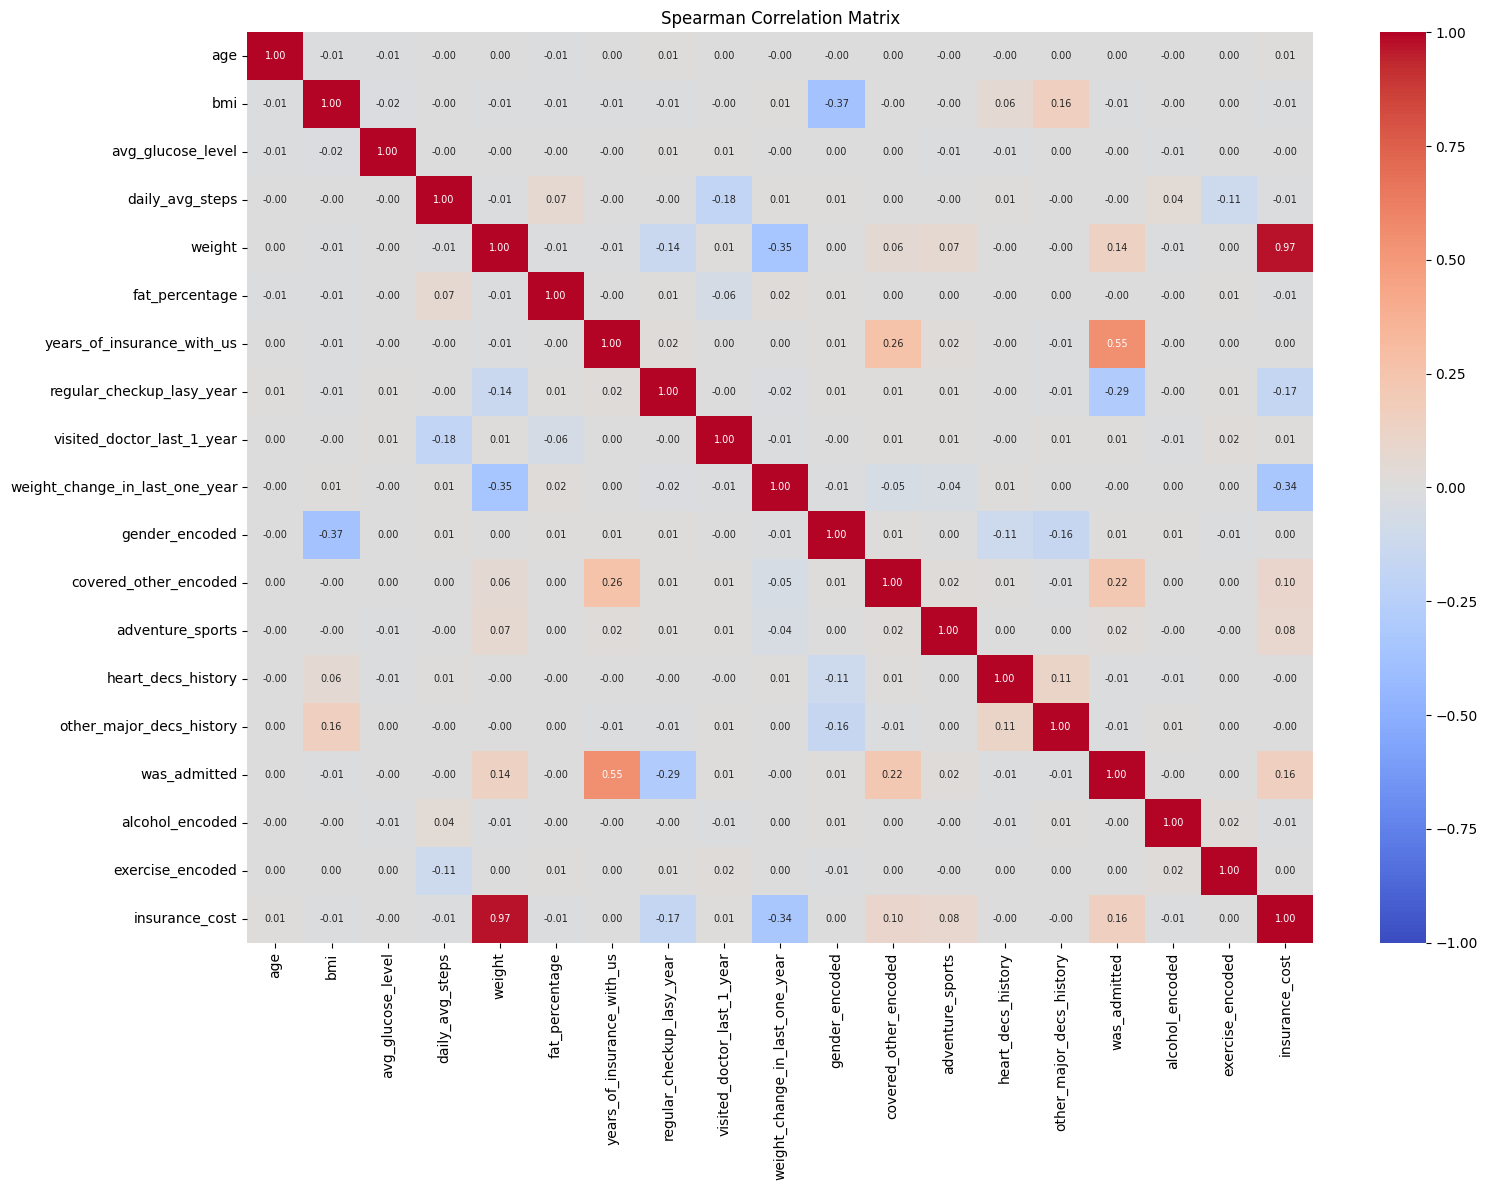

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

core_cols = ['age', 'bmi', 'avg_glucose_level', 'daily_avg_steps', 'weight', 'fat_percentage',
             'years_of_insurance_with_us', 'regular_checkup_lasy_year', 'visited_doctor_last_1_year',
             'weight_change_in_last_one_year', 'gender_encoded', 'covered_other_encoded',
             'adventure_sports', 'heart_decs_history', 'other_major_decs_history',
             'was_admitted', 'alcohol_encoded', 'exercise_encoded', 'insurance_cost']

corr_matrix = data_df[core_cols].corr(method='spearman').round(2)

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt='.2f', annot_kws={'size': 7})
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()

In [35]:
cost_corr = corr_matrix['insurance_cost'].drop('insurance_cost').sort_values(ascending=False)
print("Correlation with insurance_cost (Spearman):\n")
print(cost_corr.to_string())

Correlation with insurance_cost (Spearman):

weight                            0.97
was_admitted                      0.16
covered_other_encoded             0.10
adventure_sports                  0.08
age                               0.01
visited_doctor_last_1_year        0.01
gender_encoded                    0.00
other_major_decs_history         -0.00
heart_decs_history               -0.00
exercise_encoded                  0.00
years_of_insurance_with_us        0.00
avg_glucose_level                -0.00
bmi                              -0.01
fat_percentage                   -0.01
daily_avg_steps                  -0.01
alcohol_encoded                  -0.01
regular_checkup_lasy_year        -0.17
weight_change_in_last_one_year   -0.34


# Data Visualization

In [36]:
plot_df = pd.read_csv("Data.csv").drop_duplicates()

## 1. Distribution

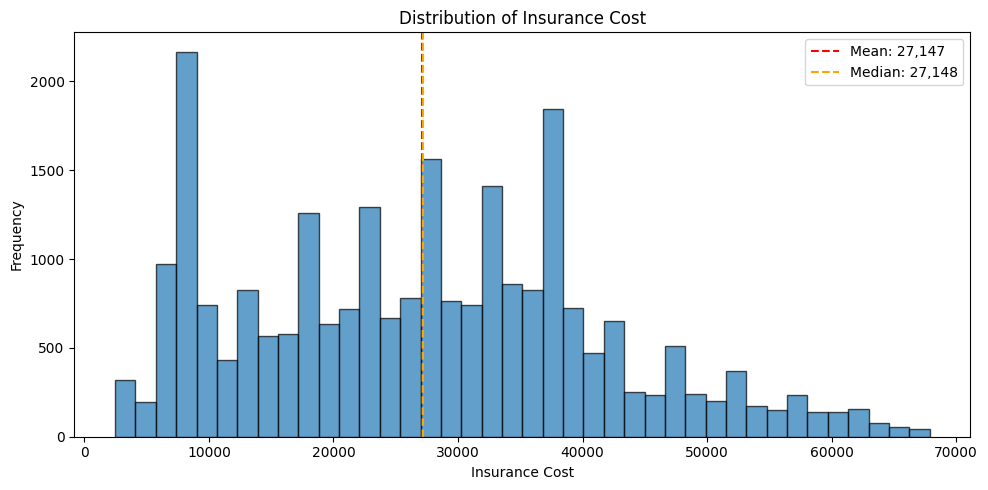

In [37]:
plt.figure(figsize=(10, 5))
plt.hist(plot_df['insurance_cost'], bins=40, edgecolor='black', alpha=0.7)
plt.axvline(plot_df['insurance_cost'].mean(), color='red', linestyle='--', label=f"Mean: {plot_df['insurance_cost'].mean():,.0f}")
plt.axvline(plot_df['insurance_cost'].median(), color='orange', linestyle='--', label=f"Median: {plot_df['insurance_cost'].median():,.0f}")
plt.xlabel('Insurance Cost')
plt.ylabel('Frequency')
plt.title('Distribution of Insurance Cost')
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
numeric_cols = ['age', 'bmi', 'avg_glucose_level', 'daily_avg_steps', 'weight', 'fat_percentage']
categorical_cols = ['Gender', 'Occupation', 'smoking_status', 'Alcohol', 'exercise', 'covered_by_any_other_company']

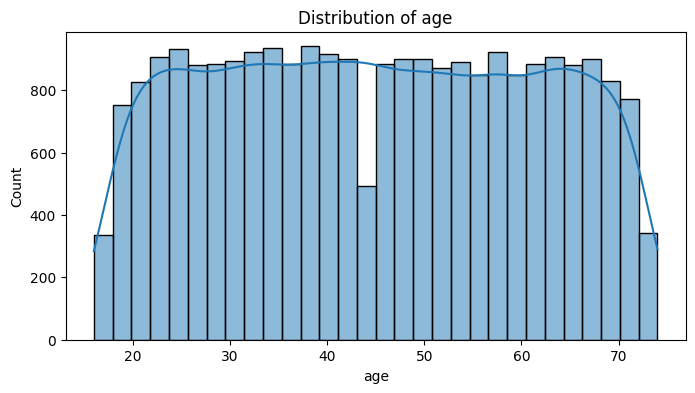

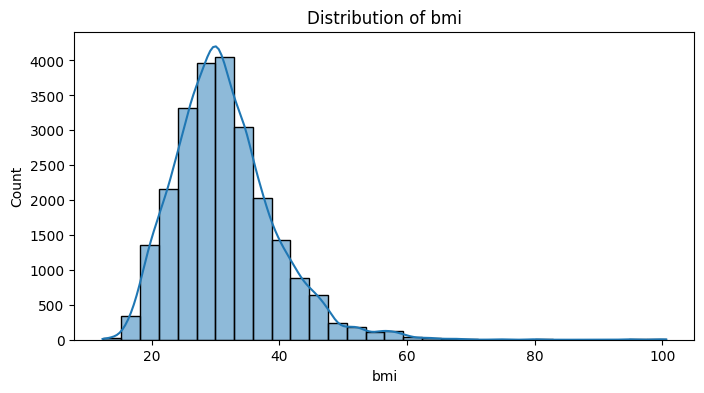

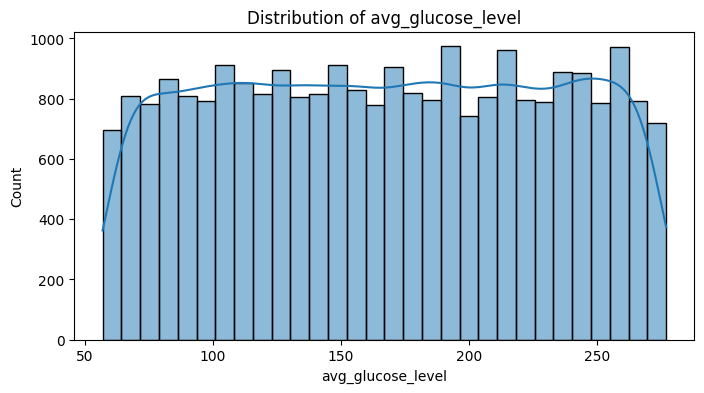

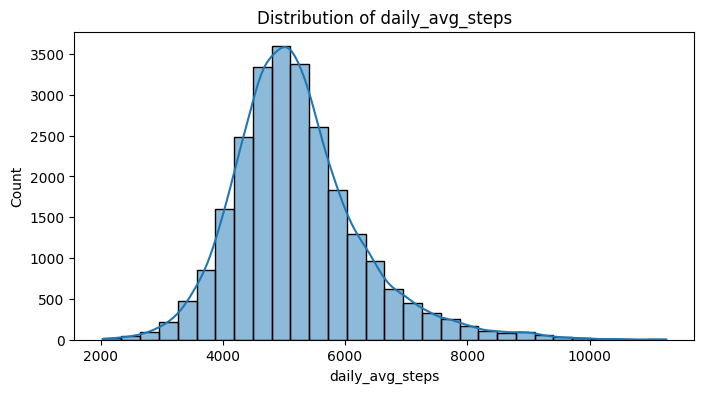

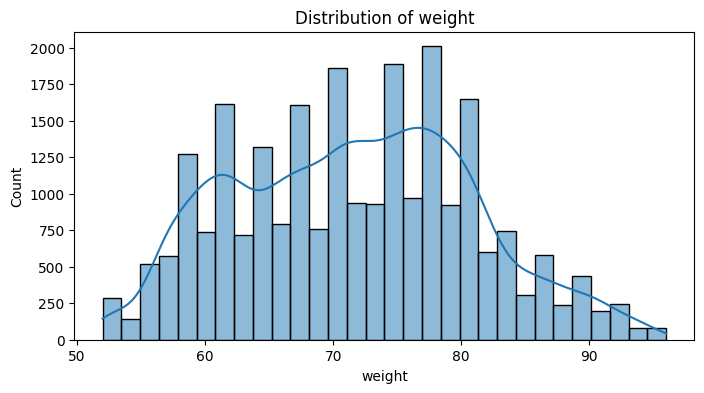

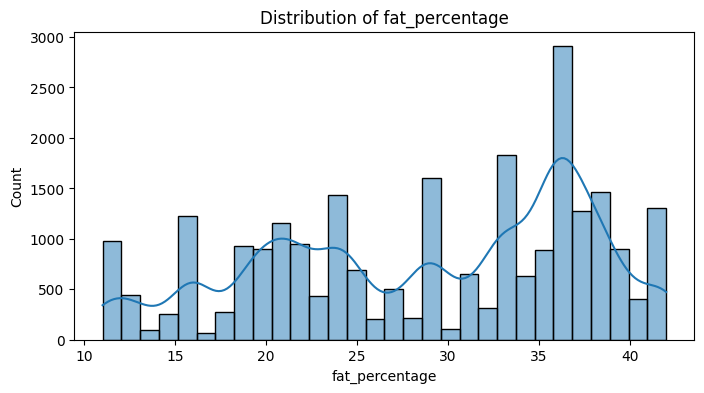

In [39]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(plot_df[col].dropna(), kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

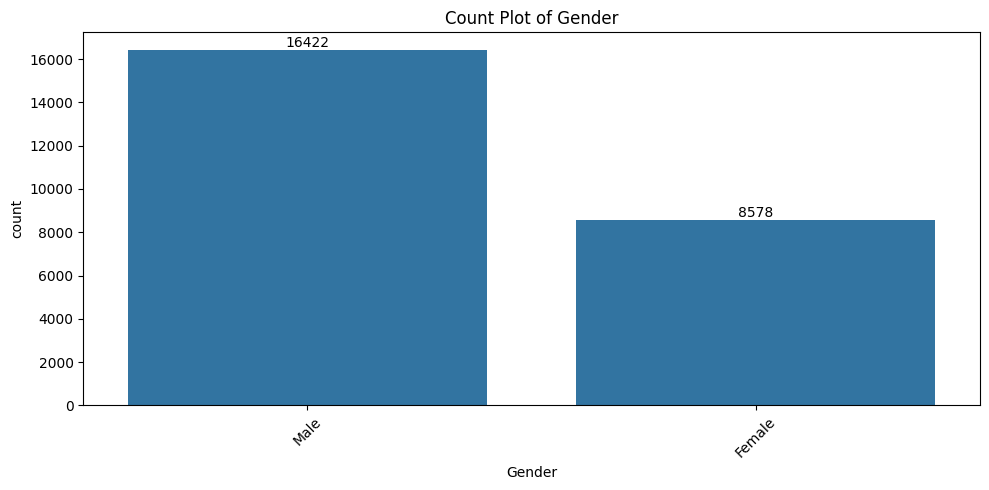

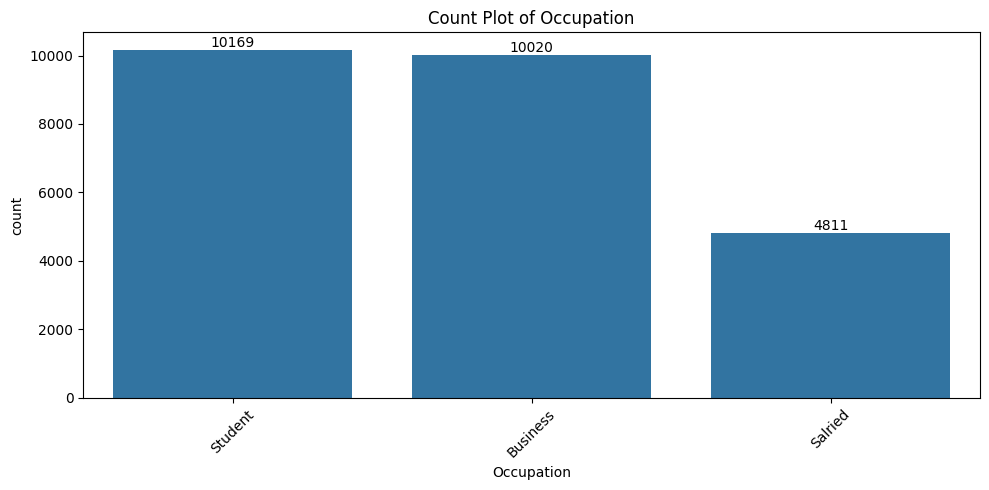

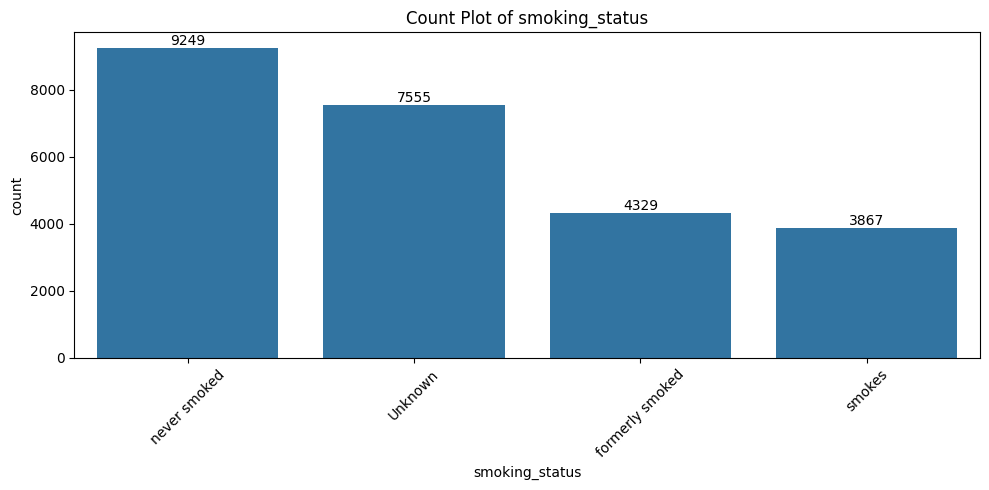

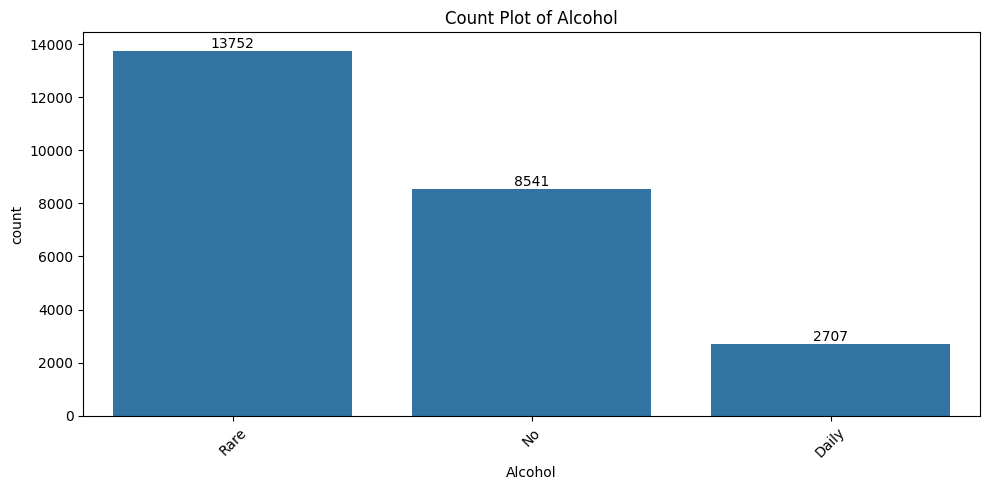

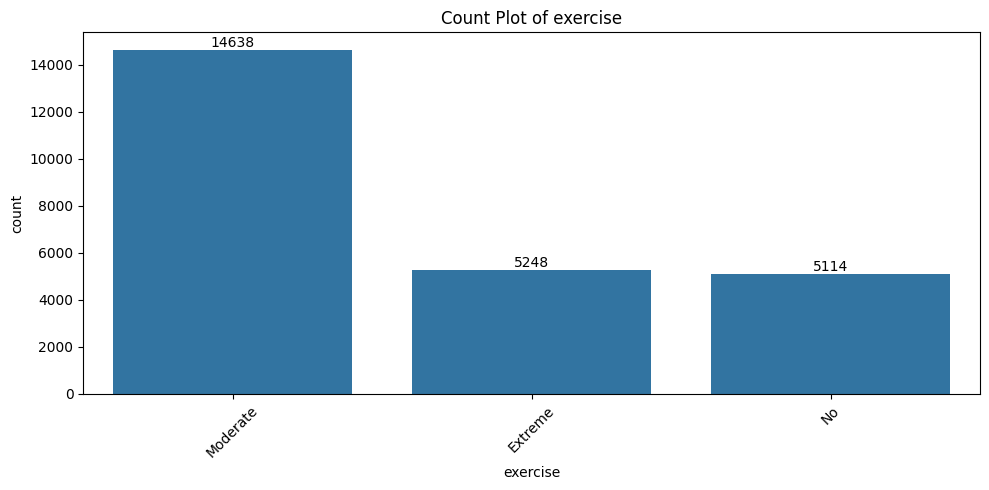

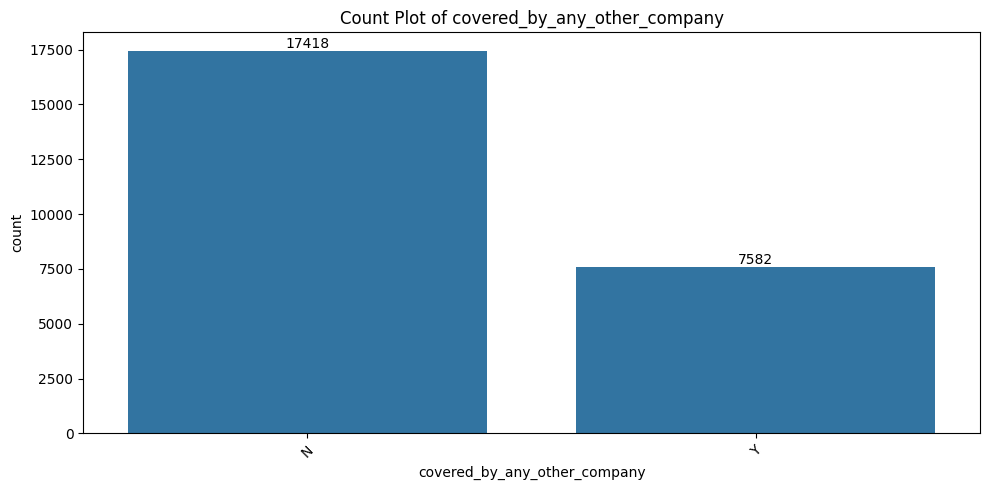

In [40]:
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(data=plot_df, x=col, order=plot_df[col].value_counts().index)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    
    for container in ax.containers:
        ax.bar_label(container)
    
    plt.tight_layout()
    plt.show()

## 2. Insurance Cost by Smoking Status

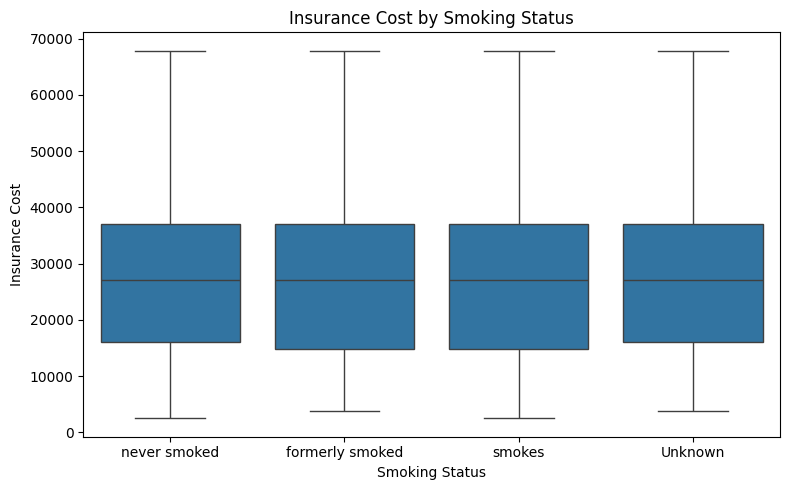

In [41]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df, x='smoking_status', y='insurance_cost',
            order=['never smoked', 'formerly smoked', 'smokes', 'Unknown'])
plt.title('Insurance Cost by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Insurance Cost')
plt.tight_layout()
plt.show()

## 3. Age vs Insurance Cost

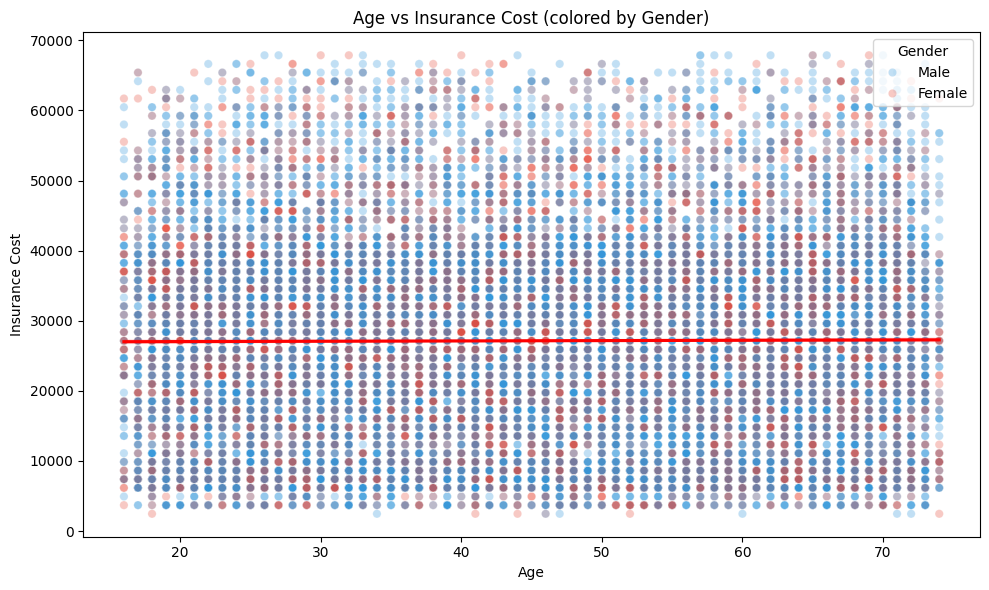

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='age', y='insurance_cost', hue='Gender', alpha=0.3,
                palette={'Male': '#3498db', 'Female': '#e74c3c'})
sns.regplot(data=plot_df, x='age', y='insurance_cost', scatter=False, color='red')
plt.title('Age vs Insurance Cost (colored by Gender)')
plt.xlabel('Age')
plt.ylabel('Insurance Cost')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

## 4. BMI vs Insurance Cost

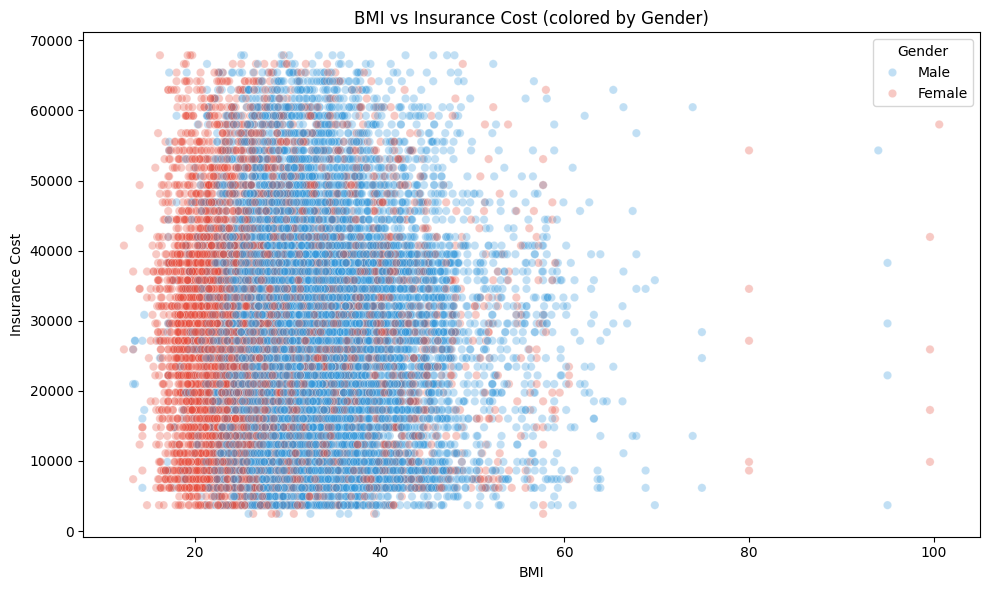

In [43]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df, x='bmi', y='insurance_cost', hue='Gender', alpha=0.3,
                palette={'Male': '#3498db', 'Female': '#e74c3c'})
plt.title('BMI vs Insurance Cost (colored by Gender)')
plt.xlabel('BMI')
plt.ylabel('Insurance Cost')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

## 5. Insurance Cost by Occupation

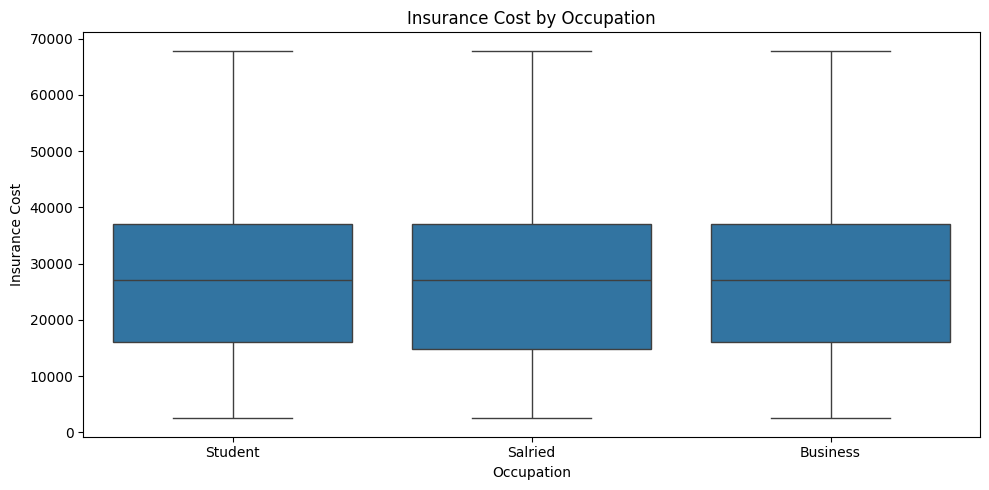

In [44]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_df, x='Occupation', y='insurance_cost',
            order=['Student', 'Salried', 'Business'])
plt.title('Insurance Cost by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Insurance Cost')
plt.tight_layout()
plt.show()

## 6. Insurance Cost by Gender and Alcohol Consumption

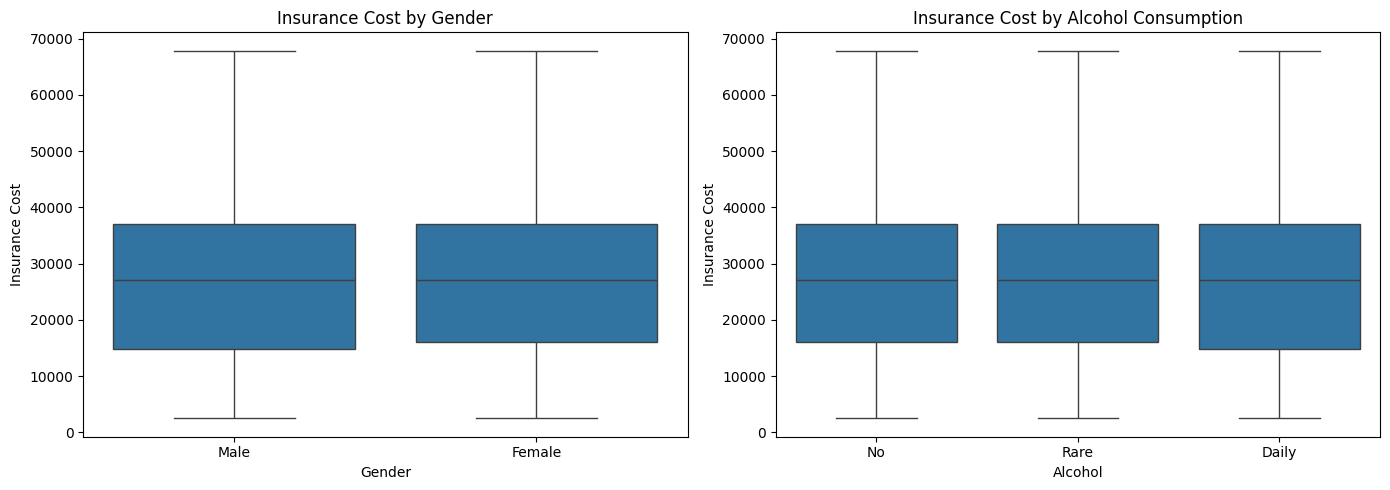

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=plot_df, x='Gender', y='insurance_cost', order=['Male', 'Female'], ax=axes[0])
axes[0].set_title('Insurance Cost by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Insurance Cost')

sns.boxplot(data=plot_df, x='Alcohol', y='insurance_cost', order=['No', 'Rare', 'Daily'], ax=axes[1])
axes[1].set_title('Insurance Cost by Alcohol Consumption')
axes[1].set_xlabel('Alcohol')
axes[1].set_ylabel('Insurance Cost')

plt.tight_layout()
plt.show()